In [ ]:
!pip uninstall -y transformers
!pip install transformers==4.49.0

Found existing installation: transformers 5.13.1
Uninstalling transformers-5.13.1:
  Successfully uninstalled transformers-5.13.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 79.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 re

In [ ]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/FakeNewsModel"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

In [ ]:
test_df = pd.read_csv("/content/drive/MyDrive/fakenewsProject/test.csv")

In [ ]:
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

In [ ]:
def tokenize(batch):
  return tokenizer(batch["text"], padding=True, truncation=True)

test_dataset =test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/11018 [00:00<?, ? examples/s]

In [ ]:
test_dataset = test_dataset.rename_column(
    "label",
    "labels"
)

In [ ]:
test_dataset = test_dataset.remove_columns([
    "text",
    "language",
    "dataset"
])

In [ ]:
test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

In [ ]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)
  precision, recall, f1, _ = precision_recall_fscore_support(
      labels,
      predictions,
      average="weighted"
  )
  acc = accuracy_score(labels, predictions)
  return {
      "accuracy": acc,
      "f1": f1,
      "precision": precision,
      "recall": recall
  }

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    report_to="none",
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/tmp/ipykernel_584/1128022173.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
import sys
import torchvision.io
class DummyVideoReader:
    pass

torchvision.io.VideoReader = DummyVideoReader

In [ ]:
results = trainer.evaluate(test_dataset)

print(results)

{'eval_loss': 0.007839650847017765, 'eval_model_preparation_time': 0.0, 'eval_accuracy': 0.9983663096750771, 'eval_f1': 0.9983663004612737, 'eval_precision': 0.9983663571036518, 'eval_recall': 0.9983663096750771, 'eval_runtime': 313.7821, 'eval_samples_per_second': 35.114, 'eval_steps_per_second': 4.392}


In [ ]:
predictions = trainer.predict(test_dataset)

In [ ]:
y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Real", "Fake"],
        digits=4
    )
)

              precision    recall  f1-score   support

        Real     0.9985    0.9981    0.9983      5339
        Fake     0.9982    0.9986    0.9984      5679

    accuracy                         0.9984     11018
   macro avg     0.9984    0.9984    0.9984     11018
weighted avg     0.9984    0.9984    0.9984     11018



In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[5329   10]
 [   8 5671]]


In [ ]:
test_df["Prediction"] = y_pred

test_df.to_csv(
    "/content/drive/MyDrive/fakenewsProject.csv",
    index=False
)

In [ ]:
test_df.columns

Index(['text', 'language', 'label', 'dataset', 'Prediction'], dtype='object')

In [ ]:
test_results = test_df.copy()

test_results["prediction"] = y_pred
test_results["correct"] = (
    test_results["label"] ==
    test_results["prediction"]
)

In [ ]:
test_results["language"] = (
    test_results["language"]
    .str.strip()
    .str.lower()
)

In [ ]:
language_count = (
    test_results["language"].
    value_counts().
    sort_values(ascending=False)
)
print(language_count)


language
english        9077
russian         539
czech           255
romanian        222
spanish         154
arabic          123
hungarian        92
italian          89
french           84
german           80
finnish          69
bulgarian        54
armenian         53
slovak           46
swedish          35
lithuanian       20
georgian         17
azerbaijani       9
Name: count, dtype: int64


In [ ]:

language_metrics = []

for language in sorted(test_results["language"].unique()):

    subset = test_results[
        test_results["language"] == language
    ]

    y_true_lang = subset["label"]
    y_pred_lang = subset["prediction"]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_lang,
        y_pred_lang,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(
        y_true_lang,
        y_pred_lang
    )

    language_metrics.append({
        "Language": language,
        "Samples": len(subset),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

In [ ]:
language_results = (
    pd.DataFrame(language_metrics)
    .sort_values(
        by="Accuracy",
        ascending=False
    )
)

language_results

,Language,Samples,Accuracy,Precision,Recall,F1
1,armenian,53,1.000000,1.000000,1.000000,1.000000
2,azerbaijani,9,1.000000,1.000000,1.000000,1.000000
12,lithuanian,20,1.000000,1.000000,1.000000,1.000000
3,bulgarian,54,1.000000,1.000000,1.000000,1.000000
4,czech,255,1.000000,1.000000,1.000000,1.000000
8,georgian,17,1.000000,1.000000,1.000000,1.000000
13,romanian,222,1.000000,1.000000,1.000000,1.000000
17,swedish,35,1.000000,1.000000,1.000000,1.000000
5,english,9077,0.999890,0.999890,0.999890,0.999890
0,arabic,123,0.991870,0.991952,0.991870,0.991808


In [ ]:
language_results.to_csv(
    "/content/drive/MyDrive/fakenewsProject/language_wise_results.csv",
    index=False
)

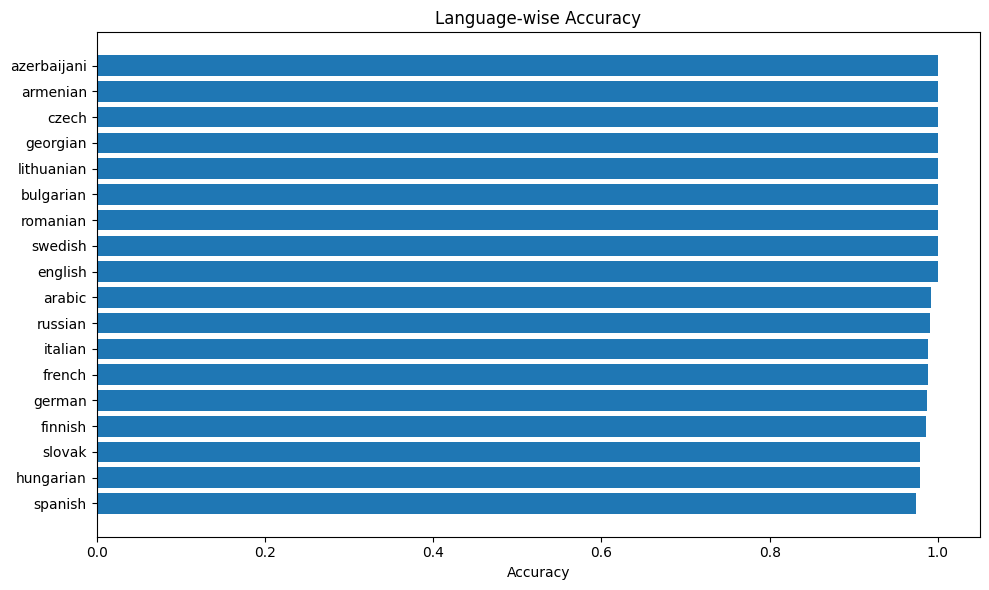

In [ ]:
import matplotlib.pyplot as plt

language_results = language_results.sort_values("Accuracy")

plt.figure(figsize=(10,6))

plt.barh(
    language_results["Language"],
    language_results["Accuracy"]
)

plt.xlabel("Accuracy")
plt.title("Language-wise Accuracy")

plt.tight_layout()
plt.show()

In [ ]:
language_results.sort_values(
    by="Accuracy"
).head(10)

,Language,Samples,Accuracy,Precision,Recall,F1
16,spanish,154,0.974026,0.974576,0.974026,0.974125
10,hungarian,92,0.978261,0.979376,0.978261,0.978346
15,slovak,46,0.978261,0.978804,0.978261,0.977562
6,finnish,69,0.985507,0.985727,0.985507,0.984527
9,german,80,0.987500,0.987750,0.987500,0.987461
7,french,84,0.988095,0.988553,0.988095,0.988161
11,italian,89,0.988764,0.989014,0.988764,0.988764
14,russian,539,0.990724,0.991207,0.990724,0.990869
0,arabic,123,0.991870,0.991952,0.991870,0.991808
5,english,9077,0.999890,0.999890,0.999890,0.999890


In [ ]:
arabic_errors = test_results[
    (test_results["language"] == "arabic") &
    (test_results["correct"] == False)
]

arabic_errors.head(10)

,text,language,label,dataset,Prediction,prediction,correct
9126,ما القرارات الإسرائيلية لتوسيع الاستيطان في ال...,arabic,0,Oligofact,1,1,False
